# Ранговый критерий Манна-Уитни: проверям гипотезу однородности 

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Mann-Whitney.ipynb

Основная идея:      
Однородность - это когда две выборки из одного распределения    
- Обычную однородность мы проверяем с помощью критерия **Колмогорова-Смирнова**. Работает для непрерывных распределений
- Если выборки дискретны, то используем **Хи-квадрат** 
- Критерий **Манна-Уитни**. Его можно применять и для дисретных, и для непрерывных распределений. Он смотрит не на сами значения выборки, а на их относительное расположение.

> Критерий Манна-Уитни более устойчив к выбросам. Важно помнить: так как он ранговый, то возможно неточная интерпретация

$H_0: F_X = F_Y$    
$H_1: F_X \neq F_Y$

Статистика:

\begin{align}
    U = \sum_{i}^N\sum_{j}^M I[A_i < B_j]
\end{align}

При нулевой гипотезе:

\begin{align}
    &U \overset{d}\rightarrow \mathcal{N}(\mathbb{E}U, \mathbb{D}U), \text{где} \\
    &\mathbb{E} U = \dfrac{NM}{2},\\
    &\mathbb{D}U = \dfrac{NM(N + M + 1)}{12}
\end{align}

В пользу альтернативы говорят большие или маленькие значения статистики, то есть гипотеза двусторонняя.     
Если статистика больше $\frac{NM}{2}$, то распределение $A$ смещено влево относительно $B$.     
Если статистика меньше $\frac{NM}{2}$, то распределение $A$ смещено вправо относительно $B$.

```python
mannwhitneyu(sample_control, sample_test, alternative='greater').pvalue # правда ли, что control больше? 
mannwhitneyu(sample_control, sample_test, alternative='less').pvalue # правда ли, что control меньше? 
```

**Почему критерий ранговый?**

Потому что статистику $U$ можно переписать как 

\begin{align}
    &U = V - \dfrac{M (M + 1)}{2}, \text{где} \\ 
    &R_j \ \text{- ранг}  \ B_j \text{ в выборке } (A_1,\ ...,\ A_N,\ B_1,\ ...,\ B_M) \\
    &V = R_1 +\ ...\ + R_M
\end{align}

> в таком виде статистику посчитать быстрее: достаточно отсортировать за $N
\log(N)$, а в исходном виде работает за квадратичное время

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

MannwhitneyuResult(statistic=np.float64(2406.0), pvalue=np.float64(1.6414649060209875e-15))
Значение статистики вручную: 94.000
Pvalue вручную: 0.000
Center = 1250.0


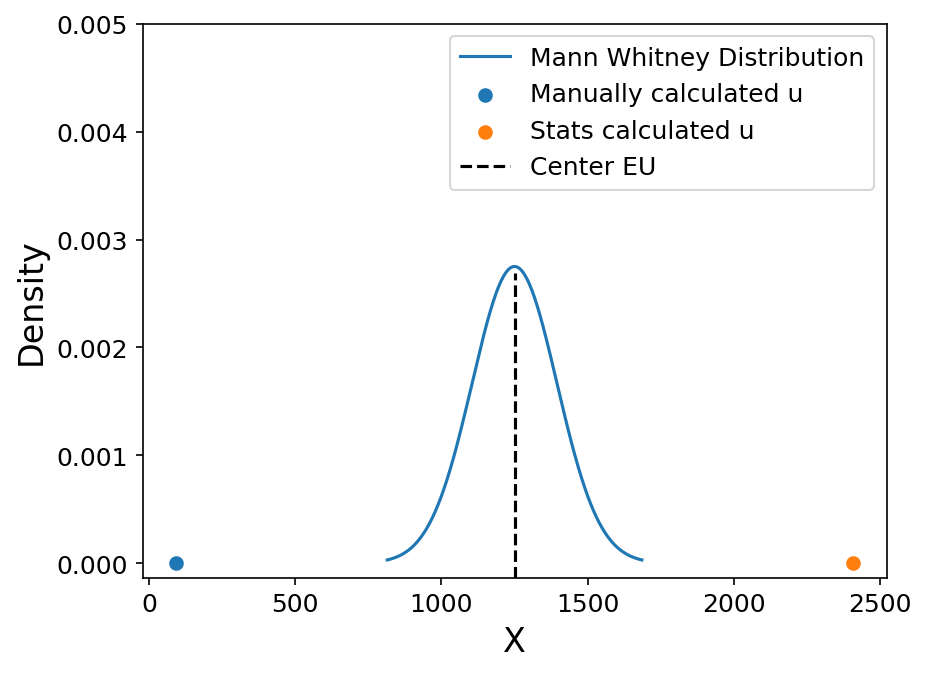

In [ ]:
# Применим критерий 

# В общем, оказывается, что в библиотеке там будет сумметрично

distr_a = stats.norm(loc=6, scale=1)
distr_b = stats.norm(loc=3, scale=1)

np.random.seed(8)

N = 50
M = 50

sample_a = distr_a.rvs(N)
sample_b = distr_b.rvs(M)

# Calculating manually
EU = N * M / 2
DU = np.sqrt(N * M * (N + M + 1) / 12)
mann_whitney_dist = stats.norm(loc=EU, scale=DU)
x = np.linspace(EU - 3 * DU, EU + 3 * DU, 1000)

def calculate_U(A, B):
    """
        Функция для подсчета статистики U
    """
    U = 0
    for A_elem in A:
        for B_elem in B:
            U += A_elem < B_elem
    return U

u = calculate_U(sample_a, sample_b)
pvalue = 2 * min(mann_whitney_dist.cdf(u), 1 - mann_whitney_dist.cdf(u))

# Calculating from library
res = stats.mannwhitneyu(sample_a, sample_b)
print(res)

print(f"Значение статистики вручную: {u:.3f}")
print(f"Pvalue вручную: {pvalue:.3f}")
print(f"Center = {EU}")

plt.plot(x, mann_whitney_dist.pdf(x), label='Mann Whitney Distribution')
plt.scatter(u, 0, label='Manually calculated u')
plt.scatter(res.statistic, 0, label='Stats calculated u')
plt.axvline(EU, ymax=mann_whitney_dist.pdf(EU) / 0.005, linestyle='--', c='black', label='Center EU')
plt.ylim(top=0.005)
plt.xlabel('X')
plt.ylabel('Density')
plt.legend()

In [45]:
stats.mannwhitneyu(sample_b, sample_a, alternative='greater').pvalue

np.float64(0.9999999999999992)

100%|██████████| 3000/3000 [00:06<00:00, 444.81it/s]


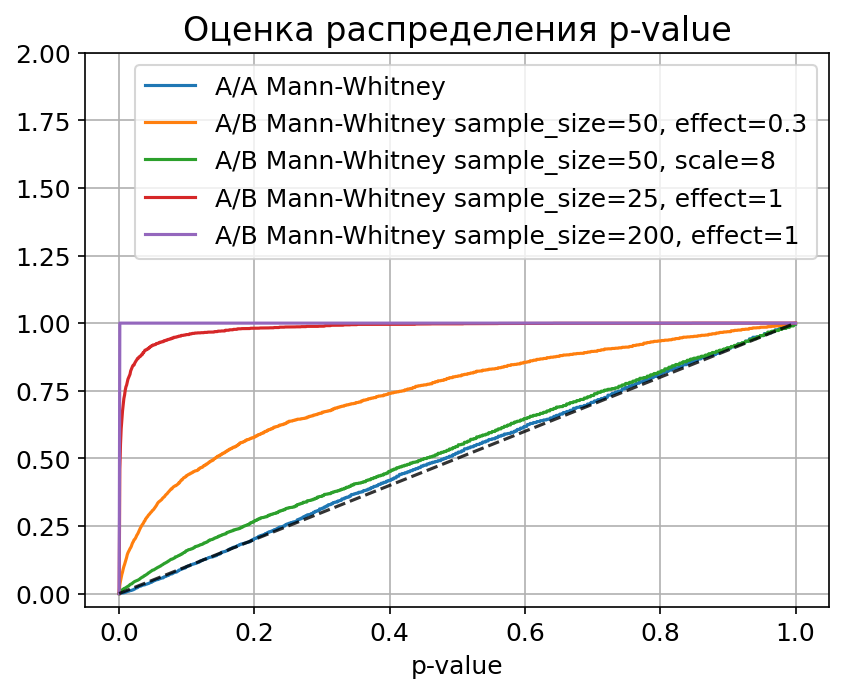

In [21]:
# Проверяем корретность критерия

# Видно, что при изменении дисперсии мощность очень маленькая, что логично, 
# так как этот критерй устойчив к выбросам

def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.ylim(top=2)
    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

alpha = 0.05
sample_size = 50
effect = 1

# Monte Carlo to estimate pvalues and check correctness
dict_pvalues = defaultdict(list)
n_iter = 3000
for _ in tqdm(range(n_iter)):
    df_control = pd.DataFrame(stats.norm(loc=1, scale=1).rvs(sample_size), columns=['metric'])
    df_test_aa = pd.DataFrame(stats.norm(loc=1, scale=1).rvs(sample_size), columns=['metric'])
    df_test_ab = pd.DataFrame(stats.norm(loc=1+0.3, scale=1).rvs(sample_size), columns=['metric']) # low effect
    df_test_ab_scale = pd.DataFrame(stats.norm(loc=1, scale=8).rvs(sample_size), columns=['metric']) # change scale

    dict_pvalues['A/A Mann-Whitney'].append(stats.mannwhitneyu(df_control['metric'], df_test_aa['metric']).pvalue)

    dict_pvalues[f'A/B Mann-Whitney sample_size={sample_size}, effect={0.3}'].append(stats.mannwhitneyu(df_control['metric'], df_test_ab['metric']).pvalue)
    dict_pvalues[f'A/B Mann-Whitney sample_size={sample_size}, scale={8}'].append(stats.mannwhitneyu(df_control['metric'], df_test_ab_scale['metric']).pvalue)

    for sz in [25, 200]:
        df_control = pd.DataFrame(stats.norm(loc=1, scale=1).rvs(sz), columns=['metric'])
        df_test_ab = pd.DataFrame(stats.norm(loc=1+effect, scale=1).rvs(sz), columns=['metric'])
        dict_pvalues[f'A/B Mann-Whitney sample_size={sz}, effect={effect}'].append(stats.mannwhitneyu(df_control['metric'], df_test_ab['metric']).pvalue)

plot_pvalue_distribution(dict_pvalues)

Text(0.5, 1.0, 'Распеделение ARPU')

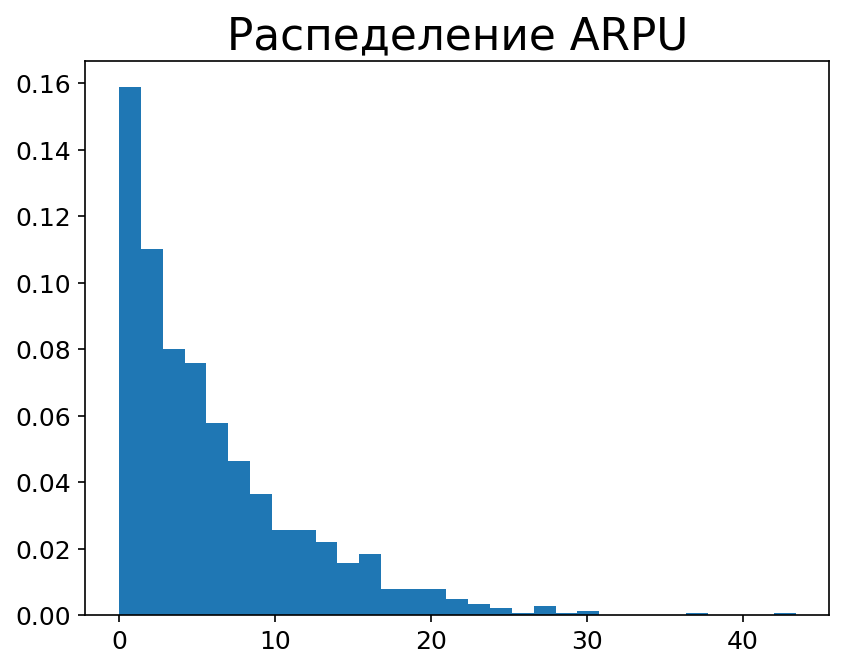

In [53]:
# Решаем задачу: выдали скидки.
# Было: 50% платящих пользователей. Стало: 55% платящих пользователей 
# Было: ARPU = 7. Стало: ARPU = 6
# Хотим понять, правда ли, что EC (expectation control) 
# отличается от ET (expectation test)

# Моделируем распределение ARPU как экспоненциальное 

plt.hist(stats.expon(loc=0, scale=6).rvs(1000), bins='auto', density=True)
plt.title('Распеделение ARPU')

In [ ]:
# Тут у нас разные распределения, E (control) > E (test)
# И мы смотрим долю случаев, когда критерий ошибся, то есть сказал, что E (control) < E (test)
# оказался 84% процента! 
# То есть мы бы выкатили изменение
# Вывод: не применять критерий Манна Уитни для проверки гипотезы о равенстве средних

alpha = 0.05
sample_size = 5000

mann_wrong_rollout = [] # wrong rollout rate
ttest_wrong_rollout = [] # wrong rollout rate

# Run Monte Carlo
n_iter = 1000
for _ in range(n_iter):
    control = stats.expon(loc=0, scale=7).rvs(sample_size) * stats.binom(1, 0.5).rvs(sample_size) # EC = 3.5
    test = stats.expon(loc=0, scale=6).rvs(sample_size) * stats.binom(1, 0.55).rvs(sample_size) # EC=3.3

    # Is contol < test?
    pvalue_mann = stats.mannwhitneyu(control, test, alternative='less').pvalue
    pvalue_ttest = stats.ttest_ind(control, test, alternative='less').pvalue

    mann_wrong_rollout.append(pvalue_mann <= alpha)
    ttest_wrong_rollout.append(pvalue_ttest <= alpha)

mann_wrong_rollout = np.array(mann_wrong_rollout)
ttest_wrong_rollout = np.array(ttest_wrong_rollout)

WrongRolloutMann = np.mean(mann_wrong_rollout)
WrongRolloutTtest = np.mean(ttest_wrong_rollout)

ci_left_mann, ci_right_mann = proportion_confint(count=np.sum(mann_wrong_rollout), nobs=len(mann_wrong_rollout), alpha=0.05)
ci_left_ttest, ci_right_ttest = proportion_confint(count=np.sum(ttest_wrong_rollout), nobs=len(ttest_wrong_rollout), alpha=0.05)

print(f"Mann Whitney: Wrong Rollout Rate = {WrongRolloutMann:.3f}, CI = [{ci_left_mann:.3f}, {ci_right_mann:.3f}]")
print(f"Ttest: Wrong Rollout Rate = {WrongRolloutTtest:.3f}, CI = [{ci_left_ttest:.3f}, {ci_right_ttest:.3f}]")

Mann Whitney: Wrong Rollout Rate = 0.850, CI = [0.828, 0.872]
Ttest: Wrong Rollout Rate = 0.001, CI = [0.000, 0.003]
